# **逻辑回归**

## 数学知识

**联合概率**: 多个事件同时发生的概率.$P(A\cap B)$ 或 $P(A,B)$,事件A和事件B同时发生的概率.

**条件概率**: 已知一个事件发生的条件下,另一个事件发生的概率.$P(B|A)$ 事件B在事件A发生的条件下发生的概率.

**对数函数**: $a^b = N$($a>0$ 且 $a\neq1$,$N>0$),$b$叫做以$a$为底$N$的对数,记作$b=\log_aN$

1. $log_aMN = log_aM+log_aN$

2. $log_aN^b = b\log_aN$

3. $log_a\frac{N}{M} = log_aN-log_aM$

## **原理**

逻辑回归是一个**二分类**模型,将线性回归的连续输出通过**Sigmoid**函数转换为**概率值**,根据给定的阈值,将样本划分为**正样本**和**负样本**。

### **Sigmoid函数**:



$$z = w_0+w_1x_1+w_2x_2+...+w_nx_n = w^Tx$$

$$ P(y=1∣x) = \sigma(z) = \frac{1}{1+e^{-z}} $$


- $P(y=1∣x)$表示在给定特征$x$的条件下,样本属于正类(通常标记为1)的概率.

- $z$：输入值（可以是任意实数）

- $e$：自然常数，约等于2.71828

- $σ(z)$：输出值，在(0,1)之间

### **损失函数**



逻辑回归使用**交叉熵损失函数**(也叫对数损失),而不是线性回归中的均方误差

$$L(w) = -\sum_{i=1}^n[y_i\log(p_i)+(1-y_i)\log(1-p_i)]$$

- $p_i$: sigmoid函数的输出值$P(y=1∣x)$

 - $y_i$: 第$i$个样本的真实标签(0或1),$y_i=0$表示第 $i$ 个样本实际属于**负样本**(通常标记为0),$y_i=1$表示第 $i$ 个样本实际属于**正样本**(通常标记为1)


损失函数的原理:每个样本有两个类别,**真实类别对应的位置,值越大越好**.在损失函数中，我们希望通过模型预测的概率$p_i$ (即模型认为该样本属于正类的概率)与真实标签 $y_i$ 尽可能接近

### **混淆矩阵**

- **True**:真
- **False**:假(伪)
- **Positive**:正例
- **Negative**:负例(反例,假例)

 || 预测值正例 | 预测值负例 |
 |------------|-----------|------|
 | 真实值正例 | 真正例**TP** | 伪反例**FN** |
 | 真实值负例 | 伪正例**FP** | 真反例**TN** |

 - 真实值是**正例**的样本中,被分类为**正例**的样本数量,叫做**真正例(TP,True Positive)**
 - 真实值是**正例**的样本中,被分类为**负例**的样本数量,叫做**伪反例(FN,False Negative)**
 - 真实值是**负例**的样本中,被分类为**正例**的样本数量,叫做**伪正例(FP,False Positive)**
 - 真实值是**负例**的样本中,被分类为**负例**的样本数量,叫做**真反例(TN,True Negative)**





**TP**+**TN**+**FP**+**FN**=**样本总数**

#### **精确率**(precision)

**精确率**:也叫查准率,对正例样本的预测准确率.比如:把恶性肿瘤当作正例样本,想知道模型对恶性肿瘤的预测准确度.
$$P = \frac{TP}{TP+FP}$$

公式可以理解为:真正例(TP)在被预测为正例的样本数量(TP+FP)中所占的比例.

#### **召回率**(recall)


**召回率**:也叫查全率,预测为**真正例**样本占所有**真实值正例**样本的比例.比如:把恶性肿瘤当作正例样本,想知道模型是否能把所的恶性肿瘤都预测出来.
$$R = \frac{TP}{TP+FN}$$

#### **F1值**(F1 score)


**F1值**:也叫F1分数,是精确率和召回率的调和平均值.想知道模型在召回率和精确率的评估能力. 
$$F1 = \frac{2 \times P \times R}{P + R}$$

#### 混淆矩阵_Confusion Matrix_代码演示

已知有10个样本,有6个恶性肿瘤样本,4个良性肿瘤样本.我们假设恶性肿瘤为正例.

模型A预测对了3个恶性肿瘤样本,4个良性肿瘤样本.

模型B预测对了6个恶性肿瘤样本,1个良性肿瘤样本.

根据上述数据集,搭建混淆矩阵,分别计算模型A和模型B的精确率,召回率,F1值.

In [12]:
import pandas as pd
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score, f1_score,recall_score

y_train =  ['恶性','恶性','恶性','恶性','恶性','恶性',  '良性','良性','良性','良性']
#模型A预测三个恶性肿瘤,4个良性肿瘤
y_pred_A = ['恶性','恶性','恶性','良性','良性','良性',  '良性','良性','良性','良性']
#模型B预测对了6个恶性肿瘤,1个良性肿瘤
y_pred_B = ['恶性','恶性','恶性','恶性','恶性','恶性',  '良性','恶性','恶性','恶性']
#用标签标记正例和反例
labels = ['恶性(正)','良性(反)']

#使用真实值和模型A的预测结果 搭建混淆矩阵
cm_A = confusion_matrix(y_train, y_pred_A)
df_A = pd.DataFrame(cm_A, index=labels, columns=labels)
print("模型A的混淆矩阵:\n",df_A)
print('****************************************************')
#使用真实值和模型B的预测结果 搭建混淆矩阵
cm_B = confusion_matrix(y_train, y_pred_B)
df_B = pd.DataFrame(cm_B, index=labels, columns=labels)
print("模型B的混淆矩阵:\n",df_B)
print('****************************************************')
#计算模型A的准确率,精确率,F1值,召回率
print("模型A的准确率:",accuracy_score(y_train, y_pred_A))
print("模型A的精确率:",precision_score(y_train, y_pred_A, pos_label='恶性'))
print("模型A的F1值:",f1_score(y_train, y_pred_A, pos_label='恶性'))
print("模型A的召回率:",recall_score(y_train, y_pred_A, pos_label='恶性'))

print('****************************************************')

#计算模型B的准确率,精确率,F1值,召回率
print("模型B的准确率:",accuracy_score(y_train, y_pred_B))
print("模型B的精确率:",precision_score(y_train, y_pred_B, pos_label='恶性'))
print("模型B的F1值:",f1_score(y_train, y_pred_B, pos_label='恶性'))
print("模型B的召回率:",recall_score(y_train, y_pred_B, pos_label='恶性'))





模型A的混淆矩阵:
        恶性(正)  良性(反)
恶性(正)      3      3
良性(反)      0      4
****************************************************
模型B的混淆矩阵:
        恶性(正)  良性(反)
恶性(正)      6      0
良性(反)      3      1
****************************************************
模型A的准确率: 0.7
模型A的精确率: 1.0
模型A的F1值: 0.6666666666666666
模型A的召回率: 0.5
****************************************************
模型B的准确率: 0.7
模型B的精确率: 0.6666666666666666
模型B的F1值: 0.8
模型B的召回率: 1.0


### **电信客户流失预测**

1. 加载数据
数据形状: (7043, 21)

前5行数据:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

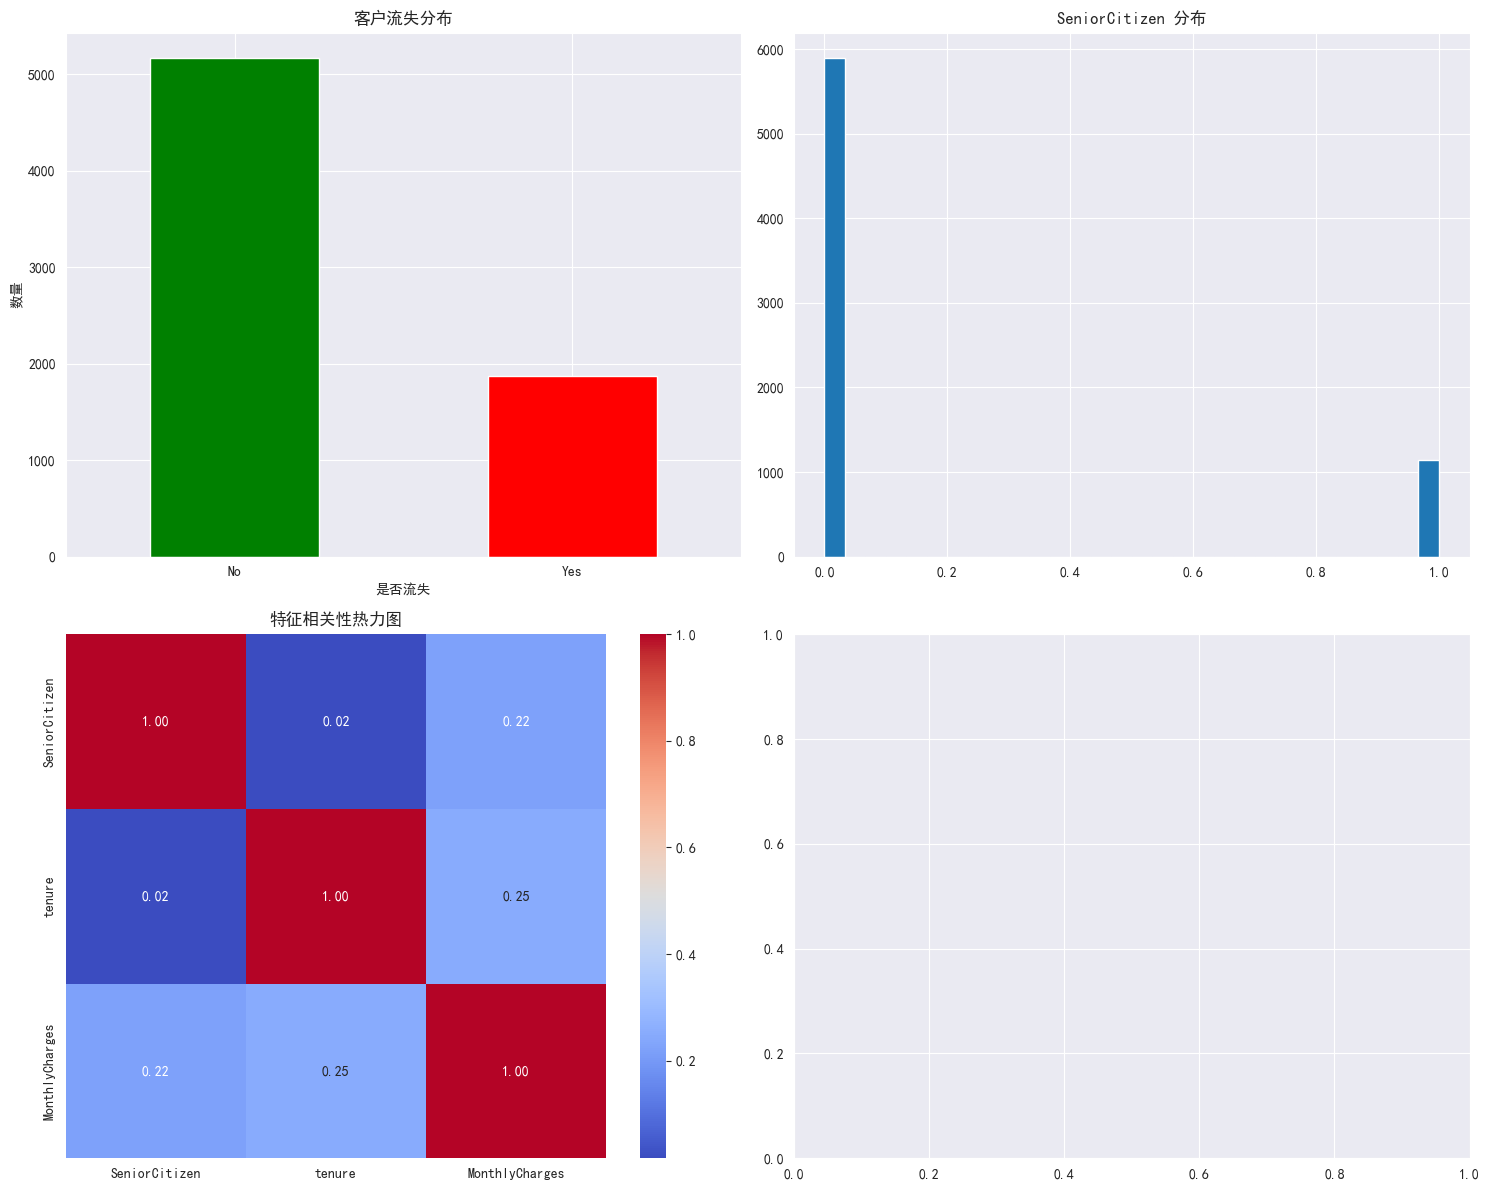


4. 数据预处理
训练集大小: (5634, 20)
测试集大小: (1409, 20)
特征数量: 20

5. 模型训练

训练 逻辑回归...
逻辑回归 - 准确率: 0.7913, 精确率: 0.6307, 召回率: 0.5160, F1: 0.5676

训练 KNN...
KNN - 准确率: 0.7473, 精确率: 0.5254, 召回率: 0.4973, F1: 0.5110

训练 决策树...
决策树 - 准确率: 0.7523, 精确率: 0.5371, 召回率: 0.4840, F1: 0.5091

训练 随机森林...
随机森林 - 准确率: 0.7935, 精确率: 0.6477, 召回率: 0.4866, F1: 0.5557

训练 梯度提升...
梯度提升 - 准确率: 0.7999, 精确率: 0.6608, 召回率: 0.5053, F1: 0.5727

训练 SVM...
SVM - 准确率: 0.7913, 精确率: 0.6460, 召回率: 0.4733, F1: 0.5463

6. 模型评估

模型性能对比:
  模型      准确率      精确率      召回率     F1分数      AUC
梯度提升 0.799858 0.660839 0.505348 0.572727 0.842420
逻辑回归 0.791341 0.630719 0.516043 0.567647 0.837877
随机森林 0.793471 0.647687 0.486631 0.555725 0.827461
 SVM 0.791341 0.645985 0.473262 0.546296 0.802277
 KNN 0.747339 0.525424 0.497326 0.510989 0.754157
 决策树 0.752307 0.537092 0.483957 0.509142 0.740843

最佳模型: 梯度提升

梯度提升 分类报告:
              precision    recall  f1-score   support

         未流失       0.84      0.91      0.87      1035
          流失       0.66    

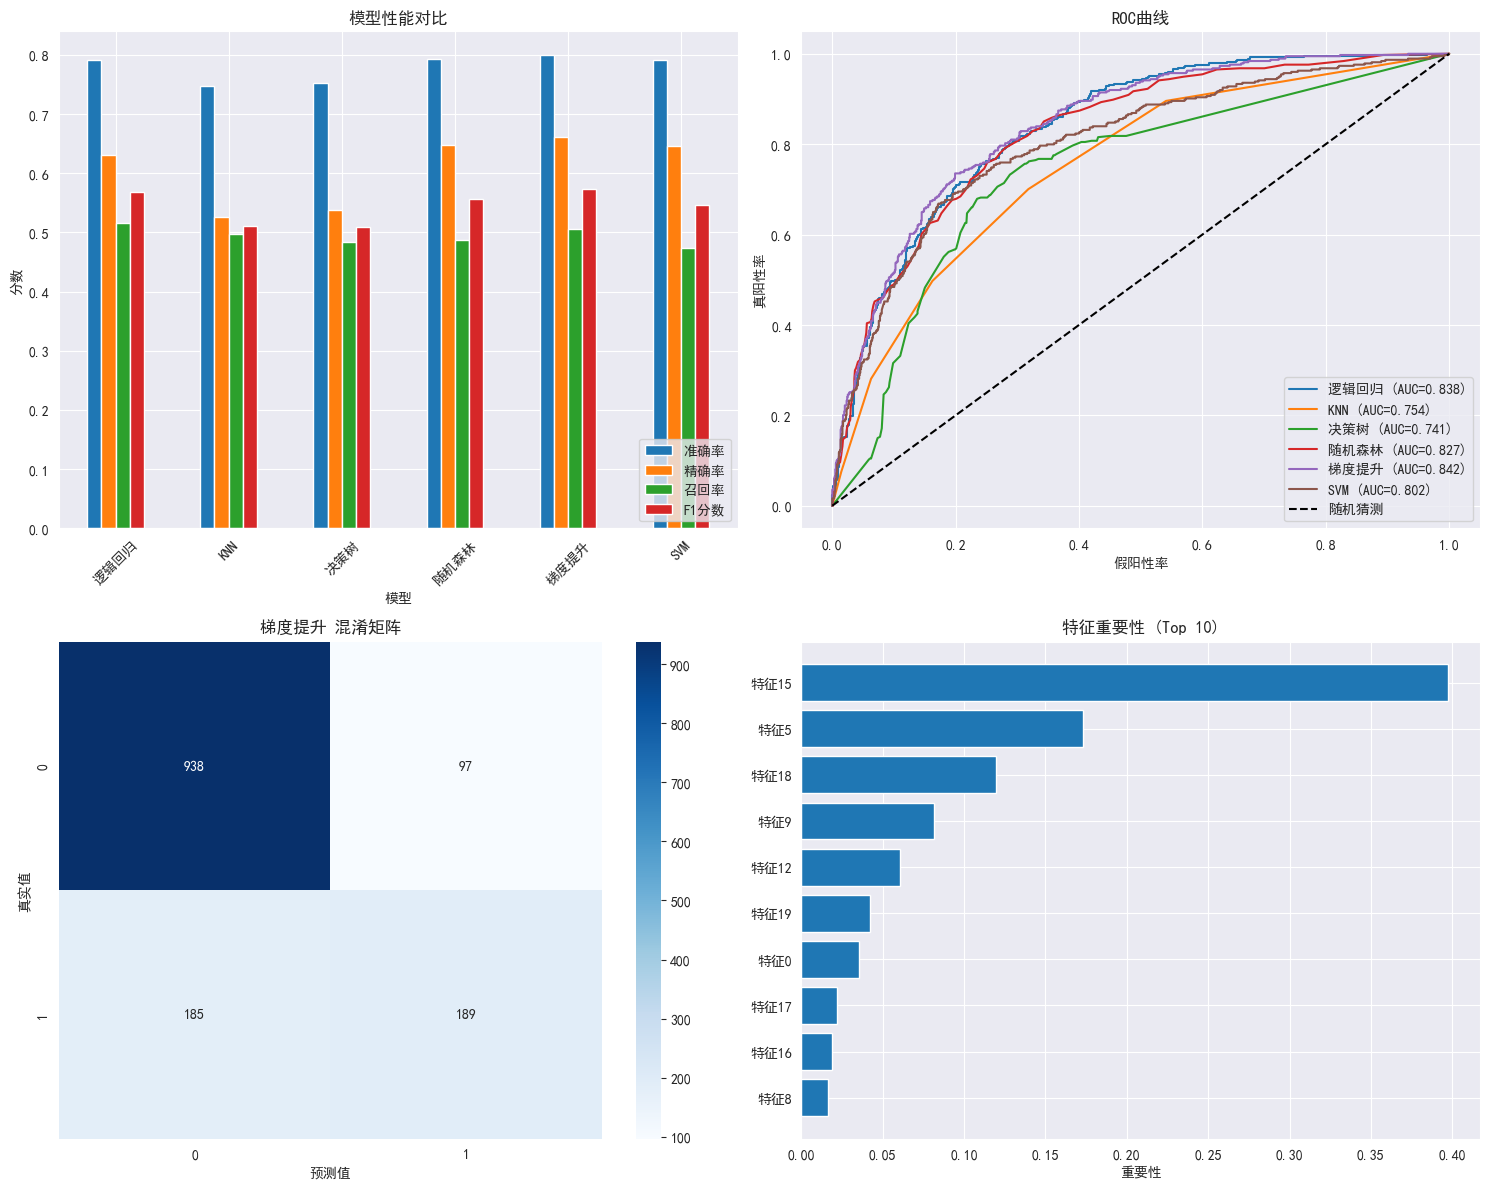


流程完成!

8. 模型优化 (可选)
可以使用GridSearchCV进行超参数调优...
最佳参数: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
最佳F1分数: 0.5740


In [2]:
"""
电信客户流失预测案例
使用机器学习算法预测客户是否会流失
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings

warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


class ChurnPrediction:
    """客户流失预测类"""

    def __init__(self, data_path):
        """初始化"""
        self.data_path = data_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}

    def load_data(self):
        """加载数据"""
        print("=" * 50)
        print("1. 加载数据")
        print("=" * 50)
        self.df = pd.read_csv(self.data_path)
        print(f"数据形状: {self.df.shape}")
        print(f"\n前5行数据:\n{self.df.head()}")
        print(f"\n数据信息:")
        print(self.df.info())
        print(f"\n数据描述:\n{self.df.describe()}")
        return self

    def explore_data(self):
        """探索性数据分析"""
        print("\n" + "=" * 50)
        print("2. 探索性数据分析")
        print("=" * 50)

        # 检查缺失值
        print(f"\n缺失值统计:")
        missing = self.df.isnull().sum()
        if missing.sum() > 0:
            print(missing[missing > 0])
        else:
            print("没有缺失值")

        # 检查目标变量分布
        if 'Churn' in self.df.columns:
            print(f"\n客户流失分布:")
            print(self.df['Churn'].value_counts())
            print(f"\n流失率: {self.df['Churn'].value_counts(normalize=True)}")

        return self

    def visualize_data(self):
        """数据可视化"""
        print("\n" + "=" * 50)
        print("3. 数据可视化")
        print("=" * 50)

        # 创建图形
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 流失分布
        if 'Churn' in self.df.columns:
            self.df['Churn'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
            axes[0, 0].set_title('客户流失分布')
            axes[0, 0].set_xlabel('是否流失')
            axes[0, 0].set_ylabel('数量')
            axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

        # 数值特征分布
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.df[numeric_cols[0]].hist(bins=30, ax=axes[0, 1])
            axes[0, 1].set_title(f'{numeric_cols[0]} 分布')

        # 相关性热力图
        if len(numeric_cols) > 1:
            corr = self.df[numeric_cols].corr()
            sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0])
            axes[1, 0].set_title('特征相关性热力图')

        # 流失率按分类特征
        categorical_cols = self.df.select_dtypes(include=['object']).columns
        if len(categorical_cols) > 0 and 'Churn' in self.df.columns:
            col = categorical_cols[0]
            if col != 'Churn' and self.df[col].nunique() < 10:
                churn_by_cat = self.df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
                churn_by_cat.plot(kind='bar', ax=axes[1, 1], stacked=True)
                axes[1, 1].set_title(f'按{col}分组的流失率')
                axes[1, 1].set_xlabel(col)
                axes[1, 1].set_ylabel('比例')

        plt.tight_layout()
        # plt.savefig('data/churn_analysis.png', dpi=300, bbox_inches='tight')
        # print("可视化图表已保存到: data/churn_analysis.png")
        plt.show()

        return self

    def preprocess_data(self):
        """数据预处理"""
        print("\n" + "=" * 50)
        print("4. 数据预处理")
        print("=" * 50)

        # 复制数据
        df_processed = self.df.copy()

        # 处理缺失值
        for col in df_processed.columns:
            if df_processed[col].isnull().sum() > 0:
                if df_processed[col].dtype in [np.float64, np.int64]:
                    df_processed[col].fillna(df_processed[col].median(), inplace=True)
                else:
                    df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

        # 编码分类变量
        label_encoders = {}
        for col in df_processed.select_dtypes(include=['object']).columns:
            if col != 'Churn':
                le = LabelEncoder()
                df_processed[col] = le.fit_transform(df_processed[col].astype(str))
                label_encoders[col] = le

        # 处理目标变量
        if 'Churn' in df_processed.columns:
            if df_processed['Churn'].dtype == 'object':
                df_processed['Churn'] = df_processed['Churn'].map(
                    {'Yes': 1, 'No': 0, 'True': 1, 'False': 0, '1': 1, '0': 0})
                if df_processed['Churn'].isnull().sum() > 0:
                    le = LabelEncoder()
                    df_processed['Churn'] = le.fit_transform(self.df['Churn'].astype(str))

        # 分离特征和目标变量
        if 'Churn' in df_processed.columns:
            X = df_processed.drop('Churn', axis=1)
            y = df_processed['Churn']
        else:
            # 如果没有Churn列,假设最后一列是目标变量
            X = df_processed.iloc[:, :-1]
            y = df_processed.iloc[:, -1]

        # 分割训练集和测试集
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # 特征标准化
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        print(f"训练集大小: {self.X_train.shape}")
        print(f"测试集大小: {self.X_test.shape}")
        print(f"特征数量: {self.X_train.shape[1]}")

        return self

    def train_models(self):
        """训练多个模型"""
        print("\n" + "=" * 50)
        print("5. 模型训练")
        print("=" * 50)

        # 定义多个模型
        self.models = {
            '逻辑回归': LogisticRegression(random_state=42, max_iter=1000),
            'KNN': KNeighborsClassifier(n_neighbors=5),
            '决策树': DecisionTreeClassifier(random_state=42, max_depth=10),
            '随机森林': RandomForestClassifier(random_state=42, n_estimators=100),
            '梯度提升': GradientBoostingClassifier(random_state=42, n_estimators=100),
            'SVM': SVC(random_state=42, probability=True)
        }

        # 训练并评估每个模型
        for name, model in self.models.items():
            print(f"\n训练 {name}...")
            model.fit(self.X_train, self.y_train)

            # 预测
            y_pred = model.predict(self.X_test)
            y_pred_proba = model.predict_proba(self.X_test)[:, 1] if hasattr(model, 'predict_proba') else None

            # 评估指标
            accuracy = accuracy_score(self.y_test, y_pred)
            precision = precision_score(self.y_test, y_pred, average='binary')
            recall = recall_score(self.y_test, y_pred, average='binary')
            f1 = f1_score(self.y_test, y_pred, average='binary')

            # 保存结果
            self.results[name] = {
                'model': model,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }

            if y_pred_proba is not None:
                auc = roc_auc_score(self.y_test, y_pred_proba)
                self.results[name]['auc'] = auc

            print(f"{name} - 准确率: {accuracy:.4f}, 精确率: {precision:.4f}, 召回率: {recall:.4f}, F1: {f1:.4f}")

        return self

    def evaluate_models(self):
        """评估模型性能"""
        print("\n" + "=" * 50)
        print("6. 模型评估")
        print("=" * 50)

        # 创建结果对比DataFrame
        results_df = pd.DataFrame({
            '模型': list(self.results.keys()),
            '准确率': [self.results[name]['accuracy'] for name in self.results],
            '精确率': [self.results[name]['precision'] for name in self.results],
            '召回率': [self.results[name]['recall'] for name in self.results],
            'F1分数': [self.results[name]['f1'] for name in self.results],
            'AUC': [self.results[name].get('auc', 0) for name in self.results]
        })

        results_df = results_df.sort_values('F1分数', ascending=False)
        print(f"\n模型性能对比:")
        print(results_df.to_string(index=False))

        # 找出最佳模型
        best_model_name = results_df.iloc[0]['模型']
        print(f"\n最佳模型: {best_model_name}")

        # 显示最佳模型的详细报告
        best_result = self.results[best_model_name]
        print(f"\n{best_model_name} 分类报告:")
        print(classification_report(self.y_test, best_result['y_pred'],
                                    target_names=['未流失', '流失']))

        # 混淆矩阵
        cm = confusion_matrix(self.y_test, best_result['y_pred'])
        print(f"\n混淆矩阵:")
        print(cm)

        return self

    def visualize_results(self):
        """可视化结果"""
        print("\n" + "=" * 50)
        print("7. 结果可视化")
        print("=" * 50)

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 模型性能对比
        results_df = pd.DataFrame({
            '准确率': [self.results[name]['accuracy'] for name in self.results],
            '精确率': [self.results[name]['precision'] for name in self.results],
            '召回率': [self.results[name]['recall'] for name in self.results],
            'F1分数': [self.results[name]['f1'] for name in self.results]
        }, index=list(self.results.keys()))

        results_df.plot(kind='bar', ax=axes[0, 0])
        axes[0, 0].set_title('模型性能对比')
        axes[0, 0].set_xlabel('模型')
        axes[0, 0].set_ylabel('分数')
        axes[0, 0].legend(loc='lower right')
        axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

        # ROC曲线
        for name, result in self.results.items():
            if result.get('y_pred_proba') is not None:
                fpr, tpr, _ = roc_curve(self.y_test, result['y_pred_proba'])
                auc = result.get('auc', 0)
                axes[0, 1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

        axes[0, 1].plot([0, 1], [0, 1], 'k--', label='随机猜测')
        axes[0, 1].set_xlabel('假阳性率')
        axes[0, 1].set_ylabel('真阳性率')
        axes[0, 1].set_title('ROC曲线')
        axes[0, 1].legend(loc='lower right')
        axes[0, 1].grid(True)

        # 最佳模型混淆矩阵
        best_model_name = max(self.results.keys(),
                              key=lambda x: self.results[x]['f1'])
        cm = confusion_matrix(self.y_test, self.results[best_model_name]['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
        axes[1, 0].set_title(f'{best_model_name} 混淆矩阵')
        axes[1, 0].set_xlabel('预测值')
        axes[1, 0].set_ylabel('真实值')

        # 特征重要性(如果是树模型)
        best_model = self.results[best_model_name]['model']
        if hasattr(best_model, 'feature_importances_'):
            importance = best_model.feature_importances_
            indices = np.argsort(importance)[-10:]  # 显示前10个重要特征
            axes[1, 1].barh(range(len(indices)), importance[indices])
            axes[1, 1].set_yticks(range(len(indices)))
            axes[1, 1].set_yticklabels([f'特征{i}' for i in indices])
            axes[1, 1].set_xlabel('重要性')
            axes[1, 1].set_title('特征重要性 (Top 10)')
        else:
            axes[1, 1].text(0.5, 0.5, f'{best_model_name}\n不支持特征重要性分析',
                            ha='center', va='center', fontsize=14)
            axes[1, 1].set_xlim(0, 1)
            axes[1, 1].set_ylim(0, 1)

        plt.tight_layout()
        # plt.savefig('data/model_results.png', dpi=300, bbox_inches='tight')
        print("结果可视化已保存到: data/model_results.png")
        plt.show()

        return self

    def run_pipeline(self, visualize=True):
        """运行完整流程"""
        self.load_data()
        self.explore_data()

        if visualize:
            self.visualize_data()

        self.preprocess_data()
        self.train_models()
        self.evaluate_models()

        if visualize:
            self.visualize_results()

        print("\n" + "=" * 50)
        print("流程完成!")
        print("=" * 50)

        return self


if __name__ == "__main__":
    # 数据文件路径
    data_path = "data/churn.csv"

    # 创建预测对象并运行
    churn_predictor = ChurnPrediction(data_path)
    churn_predictor.run_pipeline(visualize=True)

    # 可以进一步优化最佳模型
    print("\n" + "=" * 50)
    print("8. 模型优化 (可选)")
    print("=" * 50)
    print("可以使用GridSearchCV进行超参数调优...")

    # 示例: 对随机森林进行网格搜索
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5, 10]
    }

    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid_search.fit(churn_predictor.X_train, churn_predictor.y_train)

    print(f"最佳参数: {grid_search.best_params_}")
    print(f"最佳F1分数: {grid_search.best_score_:.4f}")
